In [42]:
import os

os.makedirs("reports/charts", exist_ok=True)


In [43]:
plt.savefig("reports/charts/chart_name.png")

plt.close()

In [9]:
pip install pandas numpy matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd

df = pd.read_csv("Chocolate Sales.csv")

In [5]:
df.head()

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,04-Jan-22,"$5,320",180
1,Van Tuxwell,India,85% Dark Bars,01-Aug-22,"$7,896",94
2,Gigi Bohling,India,Peanut Butter Cubes,07-Jul-22,"$4,501",91
3,Jan Morforth,Australia,Peanut Butter Cubes,27-Apr-22,"$12,726",342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24-Feb-22,"$13,685",184


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1094 entries, 0 to 1093
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Sales Person   1094 non-null   object
 1   Country        1094 non-null   object
 2   Product        1094 non-null   object
 3   Date           1094 non-null   object
 4   Amount         1094 non-null   object
 5   Boxes Shipped  1094 non-null   int64 
dtypes: int64(1), object(5)
memory usage: 51.4+ KB


In [8]:
df.shape

(1094, 6)

In [11]:
# 1. Check Missing Values
print(df.isnull().sum())


Sales Person     0
Country          0
Product          0
Date             0
Amount           0
Boxes Shipped    0
dtype: int64


In [14]:
# 2. Remove Duplicate Rows
# ------------------------------------------------
duplicates = df.duplicated().sum()
print("\nDuplicate Rows:", duplicates)

df = df.drop_duplicates()


Duplicate Rows: 0


In [15]:
# 3. Clean Column Names
# -------------------------------------------------
df.columns = df.columns.str.strip().str.replace(" ", "_")


In [16]:
# 4. Convert Date Column
# -------------------------------------------------
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

C:\Users\Admin\AppData\Local\Temp\ipykernel_1924\1342065247.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"] = pd.to_datetime(df["Date"], errors="coerce")


In [17]:
# 5. Clean Amount Column
# -------------------------------------------------
df["Amount"] = (
    df["Amount"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
)

df["Amount"] = pd.to_numeric(df["Amount"], errors="coerce")


In [21]:
# 6. Convert Boxes Shipped
# -------------------------------------------------
df["Boxes_Shipped"] = pd.to_numeric(
    df["Boxes_Shipped"],
    errors="coerce"
)

In [22]:
df = df.dropna()

In [23]:
# 8. Remove Negative Values
# -------------------------------------------------
df = df[(df["Amount"] >= 0) &
        (df["Boxes_Shipped"] >= 0)]

In [24]:
# 9. Reset Index
# -------------------------------------------------
df.reset_index(drop=True, inplace=True)


In [26]:
# 10. Save Cleaned Dataset
# -------------------------------------------------
df.to_csv("cleaned_sales.csv", index=False)

print("\nCleaning Completed Successfully")
print("Final Shape:", df.shape)

print("\nFirst 5 Rows")
print(df.head())


Cleaning Completed Successfully
Final Shape: (1094, 6)

First 5 Rows
     Sales_Person    Country              Product       Date  Amount  \
0  Jehu Rudeforth         UK      Mint Chip Choco 2022-01-04    5320   
1     Van Tuxwell      India        85% Dark Bars 2022-08-01    7896   
2    Gigi Bohling      India  Peanut Butter Cubes 2022-07-07    4501   
3    Jan Morforth  Australia  Peanut Butter Cubes 2022-04-27   12726   
4  Jehu Rudeforth         UK  Peanut Butter Cubes 2022-02-24   13685   

   Boxes_Shipped  
0            180  
1             94  
2             91  
3            342  
4            184  


In [28]:
import pandas as pd

df = pd.read_csv("cleaned_sales.csv")

print(df.head())

print("\nColumns")
print(df.columns)

print("\nData Types")
print(df.dtypes)

print("\nSummary Statistics")
print(df.describe(include="all"))

     Sales_Person    Country              Product        Date  Amount  \
0  Jehu Rudeforth         UK      Mint Chip Choco  2022-01-04    5320   
1     Van Tuxwell      India        85% Dark Bars  2022-08-01    7896   
2    Gigi Bohling      India  Peanut Butter Cubes  2022-07-07    4501   
3    Jan Morforth  Australia  Peanut Butter Cubes  2022-04-27   12726   
4  Jehu Rudeforth         UK  Peanut Butter Cubes  2022-02-24   13685   

   Boxes_Shipped  
0            180  
1             94  
2             91  
3            342  
4            184  

Columns
Index(['Sales_Person', 'Country', 'Product', 'Date', 'Amount',
       'Boxes_Shipped'],
      dtype='object')

Data Types
Sales_Person     object
Country          object
Product          object
Date             object
Amount            int64
Boxes_Shipped     int64
dtype: object

Summary Statistics
         Sales_Person    Country  Product        Date        Amount  \
count            1094       1094     1094        1094   1094.000000

 #Phase 2 :  EDA

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# Load cleaned dataset
df = pd.read_csv("cleaned_sales.csv")

print("=" * 50)
print("Dataset Overview")
print("=" * 50)

print(df.head())

print("\nShape:", df.shape)

print("\nColumns")
print(df.columns)

print("\nSummary Statistics")
print(df.describe())

print("\nData Types")
print(df.dtypes)

Dataset Overview
     Sales_Person    Country              Product        Date  Amount  \
0  Jehu Rudeforth         UK      Mint Chip Choco  2022-01-04    5320   
1     Van Tuxwell      India        85% Dark Bars  2022-08-01    7896   
2    Gigi Bohling      India  Peanut Butter Cubes  2022-07-07    4501   
3    Jan Morforth  Australia  Peanut Butter Cubes  2022-04-27   12726   
4  Jehu Rudeforth         UK  Peanut Butter Cubes  2022-02-24   13685   

   Boxes_Shipped  
0            180  
1             94  
2             91  
3            342  
4            184  

Shape: (1094, 6)

Columns
Index(['Sales_Person', 'Country', 'Product', 'Date', 'Amount',
       'Boxes_Shipped'],
      dtype='object')

Summary Statistics
             Amount  Boxes_Shipped
count   1094.000000    1094.000000
mean    5652.308044     161.797989
std     4102.442014     121.544145
min        7.000000       1.000000
25%     2390.500000      70.000000
50%     4868.500000     135.000000
75%     8027.250000     228.

In [30]:
print("\nTotal Revenue")
print("$", round(df["Amount"].sum(), 2))

print("\nTotal Boxes Sold")
print(df["Boxes_Shipped"].sum())


Total Revenue
$ 6183625

Total Boxes Sold
177007


In [31]:
top_products = (
    df.groupby("Product")["Amount"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_products)

Product
Smooth Sliky Salty     349692
50% Dark Bites         341712
White Choc             329147
Peanut Butter Cubes    324842
Eclairs                312445
99% Dark & Pure        299796
85% Dark Bars          299229
Organic Choco Syrup    294700
Spicy Special Slims    293454
Mint Chip Choco        283969
Name: Amount, dtype: int64


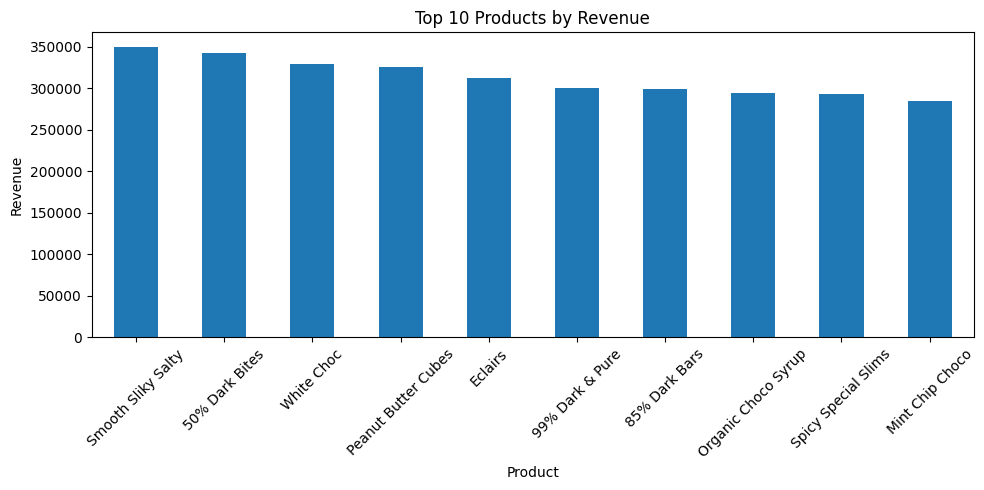

In [32]:
plt.figure(figsize=(10,5))

top_products.plot(kind="bar")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [33]:
country_sales = (
    df.groupby("Country")["Amount"]
      .sum()
      .sort_values(ascending=False)
)

print(country_sales)

Country
Australia      1137367
UK             1051792
India          1045800
USA            1035349
Canada          962899
New Zealand     950418
Name: Amount, dtype: int64


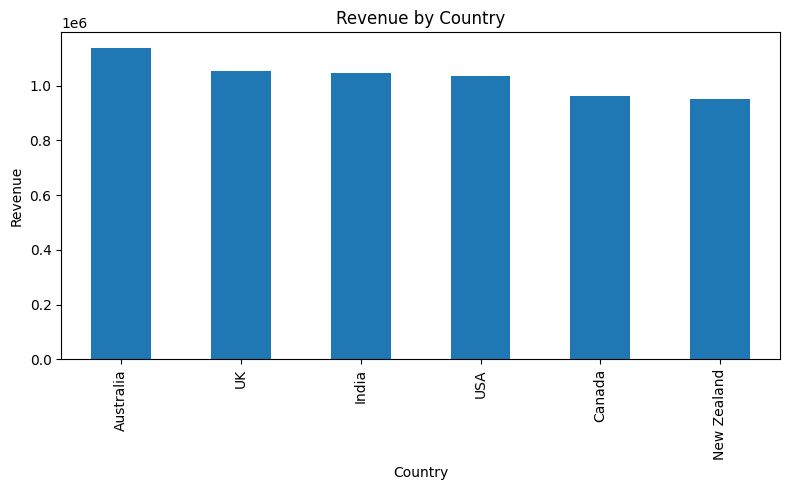

In [34]:
  # Charts
plt.figure(figsize=(8,5))

country_sales.plot(kind="bar")

plt.title("Revenue by Country")

plt.ylabel("Revenue")

plt.tight_layout()

plt.show()

In [35]:
 # Step 6: Salesperson Performance
salesperson = (
    df.groupby("Sales_Person")["Amount"]
      .sum()
      .sort_values(ascending=False)
)

print(salesperson)

Sales_Person
Ches Bonnell           320901
Oby Sorrel             316645
Madelene Upcott        316099
Brien Boise            312816
Kelci Walkden          311710
Van Tuxwell            303149
Dennison Crosswaite    291669
Beverie Moffet         278922
Kaine Padly            266490
Marney O'Breen         259742
Barr Faughny           258713
Roddy Speechley        251062
Gunar Cockshoot        238483
Gigi Bohling           232666
Karlen McCaffrey       223895
Jehu Rudeforth         220976
Jan Morforth           219667
Curtice Advani         216461
Rafaelita Blaksland    210245
Husein Augar           205212
Andria Kimpton         201747
Mallorie Waber         200592
Camilla Castle         196616
Dotty Strutley         190624
Wilone O'Kielt         138523
Name: Amount, dtype: int64


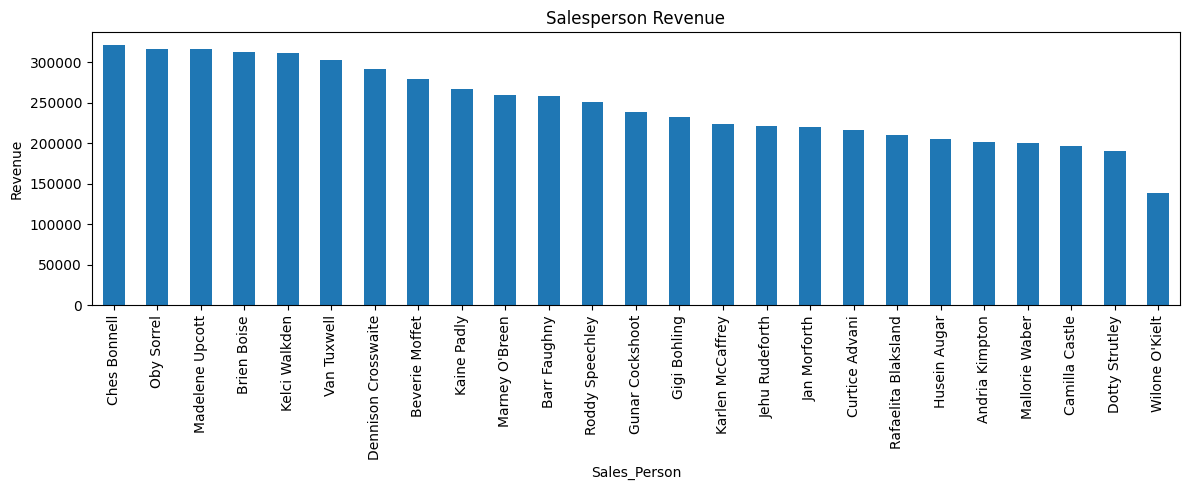

In [36]:
plt.figure(figsize=(12,5))

salesperson.plot(kind="bar")

plt.title("Salesperson Revenue")

plt.ylabel("Revenue")

plt.tight_layout()

plt.show()

In [37]:
# Monthly Revenue Trend
df["Date"] = pd.to_datetime(df["Date"])

df["Month"] = df["Date"].dt.to_period("M")

monthly_sales = (
    df.groupby("Month")["Amount"]
      .sum()
)

print(monthly_sales)

Month
2022-01    896105
2022-02    699377
2022-03    749483
2022-04    674051
2022-05    752892
2022-06    865144
2022-07    803425
2022-08    743148
Freq: M, Name: Amount, dtype: int64


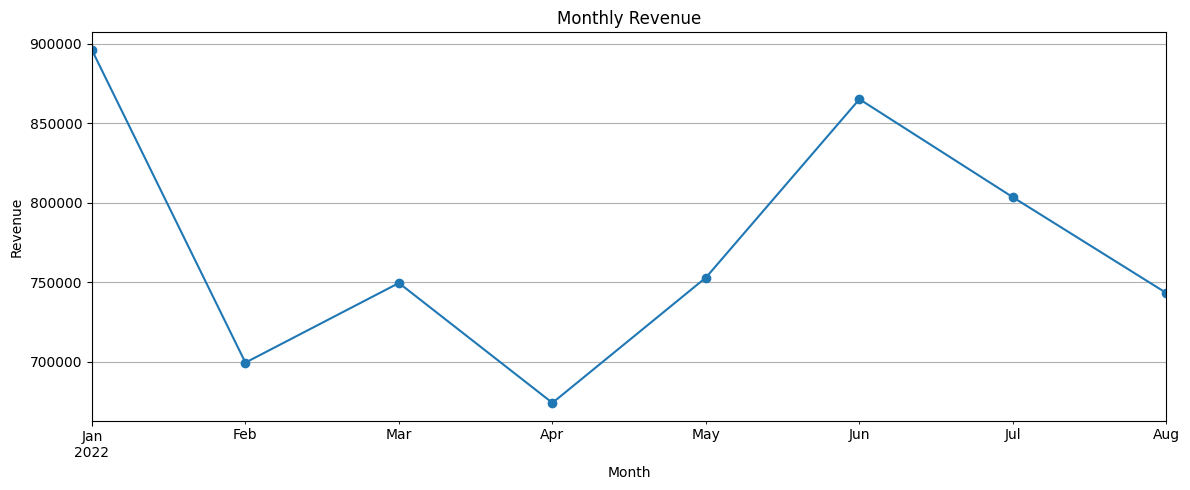

In [38]:
plt.figure(figsize=(12,5))

monthly_sales.plot(marker="o")

plt.title("Monthly Revenue")

plt.xlabel("Month")

plt.ylabel("Revenue")

plt.grid(True)

plt.tight_layout()

plt.show()

In [39]:
product_boxes = (
    df.groupby("Product")["Boxes_Shipped"]
      .sum()
      .sort_values(ascending=False)
)

print(product_boxes)

Product
50% Dark Bites          9792
Smooth Sliky Salty      8810
Eclairs                 8757
Caramel Stuffed Bars    8717
Spicy Special Slims     8685
Drinking Coco           8660
Milk Bars               8330
Peanut Butter Cubes     8304
After Nines             8257
White Choc              8240
Mint Chip Choco         8207
99% Dark & Pure         8127
70% Dark Bites          8015
85% Dark Bars           7793
Manuka Honey Choco      7781
Organic Choco Syrup     7749
Fruit & Nut Bars        7738
Orange Choco            7732
Raspberry Choco         7115
Baker's Choco Chips     6998
Almond Choco            6736
Choco Coated Almonds    6464
Name: Boxes_Shipped, dtype: int64


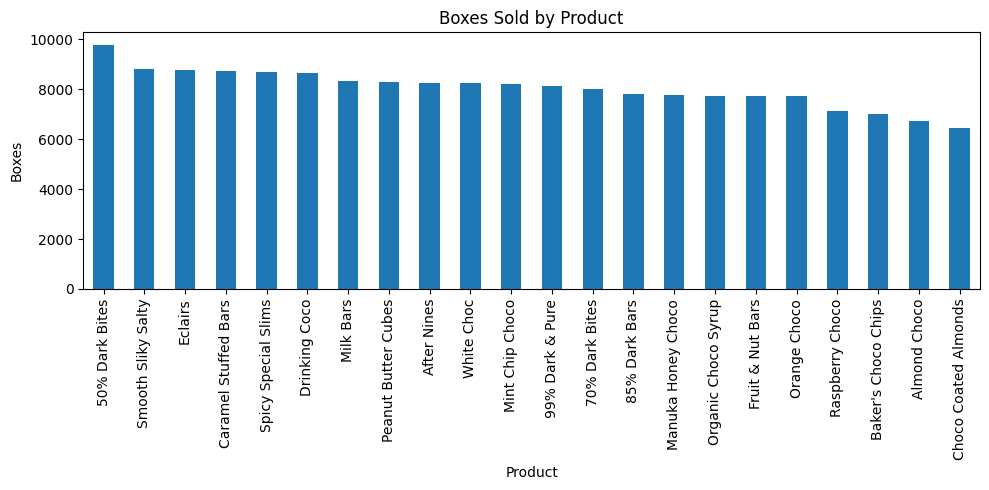

In [40]:
plt.figure(figsize=(10,5))

product_boxes.plot(kind="bar")

plt.title("Boxes Sold by Product")

plt.ylabel("Boxes")

plt.tight_layout()

plt.show()

In [41]:
# Top 10 Revenue transactions 
top_orders = (
    df.sort_values("Amount", ascending=False)
      .head(10)
)

print(top_orders)

             Sales_Person      Country              Product       Date  \
543          Ches Bonnell        India  Peanut Butter Cubes 2022-01-27   
135           Van Tuxwell        India  Organic Choco Syrup 2022-05-16   
751   Rafaelita Blaksland  New Zealand              Eclairs 2022-02-07   
66            Van Tuxwell    Australia  Organic Choco Syrup 2022-08-10   
589        Curtice Advani        India   Smooth Sliky Salty 2022-04-19   
212        Marney O'Breen           UK   Smooth Sliky Salty 2022-05-13   
1008          Kaine Padly           UK          After Nines 2022-01-21   
434          Jan Morforth  New Zealand      Mint Chip Choco 2022-06-30   
806           Brien Boise        India        85% Dark Bars 2022-08-09   
609          Jan Morforth    Australia      Mint Chip Choco 2022-02-22   

      Amount  Boxes_Shipped    Month  
543    22050            208  2022-01  
135    19929            174  2022-05  
751    19481             51  2022-02  
66     19453             14  